# Iris Flower Classification 🌸

## CodSoft Data Science Internship — Task 3

### Objective
Build a Machine Learning model to classify Iris flowers into Setosa, Versicolor, and Virginica species based on their sepal and petal measurements.

## 1. Project Overview

This project uses the Iris dataset to classify flowers into three species:

- Setosa
- Versicolor
- Virginica

The classification is based on four measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

## 2. Import Libraries and Load Dataset

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target, name='species')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Data Exploration

In [8]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
y.head()

,species
0,0
1,0
2,0
3,0
4,0


In [10]:
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [11]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [12]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [13]:
X.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


## 4. Exploratory Data Analysis

### Key Observations

- Setosa is clearly separated from the other two species.
- Versicolor and Virginica show some overlap.
- Petal length and petal width provide strong visual separation between the species.

In [14]:
print(y.value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [15]:
species_names = pd.Series(iris.target_names)

print(species_names)

0        setosa
1    versicolor
2     virginica
dtype: object


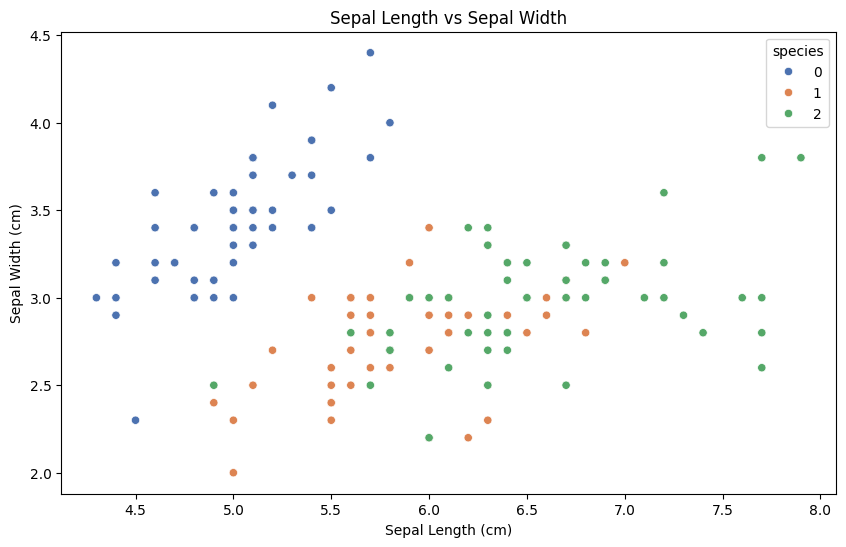

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X['sepal length (cm)'],
    y=X['sepal width (cm)'],
    hue=y,
    palette='deep'
)

plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

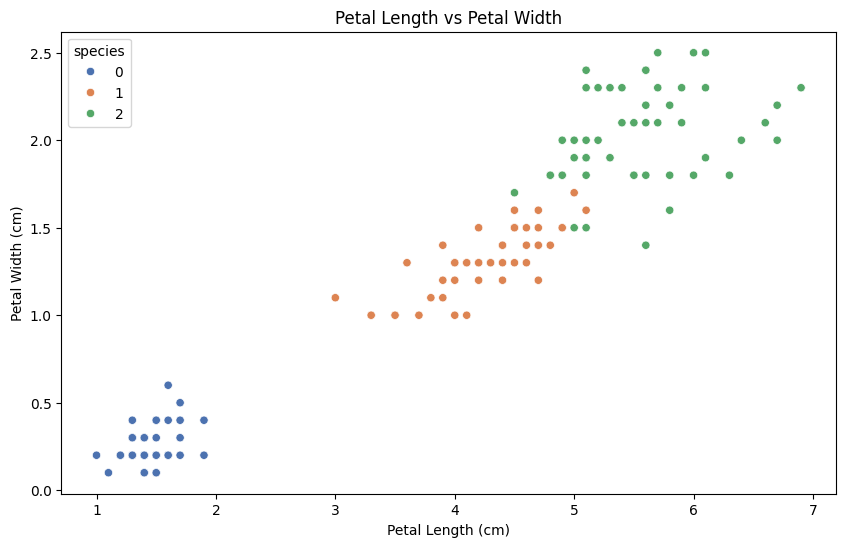

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X['petal length (cm)'],
    y=X['petal width (cm)'],
    hue=y,
    palette='deep'
)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

In [18]:
print("Features:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

Features:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

Target classes:
[0 1 2]


## 5. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


## 6. Model Training

In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 7. Prediction

In [22]:
y_pred = model.predict(X_test)

print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [23]:
print("Actual:   ", y_test.values)
print("Predicted:", y_pred)

Actual:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicted: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


## 8. Model Evaluation

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


### Result

The Logistic Regression model achieved an accuracy of **96.67%** on the test dataset.

## 9. Sample Flower Prediction

In [25]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


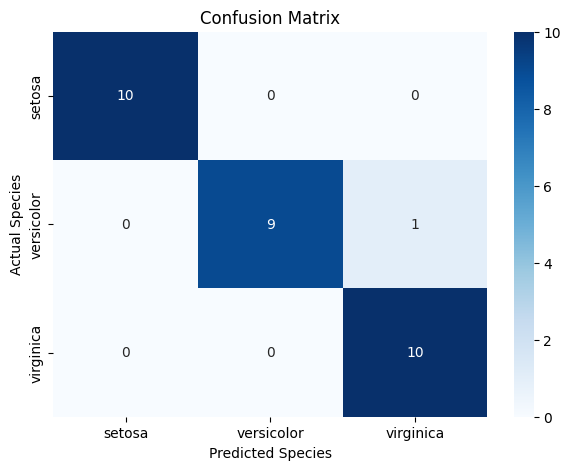

In [27]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

plt.show()

In [28]:
new_flower = pd.DataFrame({
    'sepal length (cm)': [5.1],
    'sepal width (cm)': [3.5],
    'petal length (cm)': [1.4],
    'petal width (cm)': [0.2]
})

In [29]:
prediction = model.predict(new_flower)

print("Predicted class:", prediction[0])
print("Predicted species:", iris.target_names[prediction[0]])

Predicted class: 0
Predicted species: setosa


Predicted species: setosa

## 10. Conclusion

In this project, a Logistic Regression model was developed to classify Iris flowers into Setosa, Versicolor, and Virginica.

The dataset was explored and analyzed using visualizations. The data was divided into training and testing sets, and the model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The model achieved an accuracy of **96.67%** on the test dataset.

The project demonstrates a complete Machine Learning classification workflow from data exploration to final prediction.